In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load all raw data
tbill = pd.read_csv('../data/ghana_tbill_rates.csv', parse_dates=['date'])
us_tbill = pd.read_csv('../data/us_tbill_3m.csv', parse_dates=['date'])
fed_funds = pd.read_csv('../data/fed_funds_rate.csv', parse_dates=['date'])
fx = pd.read_csv('../data/usd_ghs.csv', parse_dates=['date'])
inflation = pd.read_csv('../data/ghana_inflation.csv')
gdp = pd.read_csv('../data/ghana_gdp.csv')

print("=== Ghana T-bill ===")
print(f"Shape: {tbill.shape}, Range: {tbill['date'].min()} to {tbill['date'].max()}")
print(f"\n=== US T-bill ===")
print(f"Shape: {us_tbill.shape}, Range: {us_tbill['date'].min()} to {us_tbill['date'].max()}")
print(f"\n=== Fed Funds ===")
print(f"Shape: {fed_funds.shape}, Range: {fed_funds['date'].min()} to {fed_funds['date'].max()}")
print(f"\n=== USD/GHS ===")
print(f"Shape: {fx.shape}, Range: {fx['date'].min()} to {fx['date'].max()}")
print(f"\n=== Inflation ===")
print(inflation.head())
print(f"\n=== GDP ===")
print(gdp.head())

=== Ghana T-bill ===
Shape: (54, 5), Range: 2019-12-01 00:00:00 to 2025-12-01 00:00:00

=== US T-bill ===
Shape: (2990, 2), Range: 2015-01-01 00:00:00 to 2026-06-17 00:00:00

=== Fed Funds ===
Shape: (137, 2), Range: 2015-01-01 00:00:00 to 2026-05-01 00:00:00

=== USD/GHS ===
Shape: (2984, 2), Range: 2015-01-01 00:00:00 to 2026-06-19 00:00:00

=== Inflation ===
  economy    YR2010    YR2011     YR2012     YR2013     YR2014    YR2015  \
0     GHA  10.73339  8.728459  11.186341  11.666192  15.489616  17.14997   

      YR2016     YR2017    YR2018   YR2019   YR2020    YR2021     YR2022  \
0  17.454635  12.371922  7.808765  7.14364  9.88729  9.971089  31.255895   

      YR2023     YR2024  YR2025  
0  38.106966  22.848328     NaN  

=== GDP ===
  economy        YR2010        YR2011        YR2012        YR2013  \
0     GHA  3.219766e+10  3.933667e+10  4.127170e+10  6.284572e+10   

         YR2014        YR2015        YR2016        YR2017        YR2018  \
0  5.467853e+10  4.943681e+10  5.61

In [6]:

# US T-bill: daily → monthly average
us_tbill_monthly = us_tbill.set_index('date').resample('MS').mean().reset_index()
us_tbill_monthly = us_tbill_monthly.dropna()
print(f"US T-bill monthly: {len(us_tbill_monthly)} rows")

# USD/GHS: daily → monthly average
fx_monthly = fx.set_index('date').resample('MS').mean().reset_index()
fx_monthly = fx_monthly.dropna()
print(f"USD/GHS monthly: {len(fx_monthly)} rows")

# Fed Funds: already monthly, just rename
fed_monthly = fed_funds.copy()
print(f"Fed Funds monthly: {len(fed_monthly)} rows")

print("\nAll resampled to monthly frequency")

US T-bill monthly: 138 rows
USD/GHS monthly: 138 rows
Fed Funds monthly: 137 rows

All resampled to monthly frequency


In [7]:
# Reshape inflation: columns like YR2010 → rows
inf_cols = [c for c in inflation.columns if c.startswith('YR')]
inf_data = []
for col in inf_cols:
    year = int(col.replace('YR', ''))
    val = inflation[col].values[0]
    if pd.notna(val):
        inf_data.append({'date': pd.Timestamp(f'{year}-01-01'), 'inflation': val})

inflation_annual = pd.DataFrame(inf_data)

# Forward fill annual inflation to monthly
# Create monthly date range, then merge and ffill
monthly_dates = pd.DataFrame({
    'date': pd.date_range('2015-01-01', '2025-12-01', freq='MS')
})
inflation_monthly = monthly_dates.merge(inflation_annual, on='date', how='left')
inflation_monthly['inflation'] = inflation_monthly['inflation'].ffill()
print(f"Inflation monthly: {len(inflation_monthly)} rows")
print(inflation_monthly.tail())

Inflation monthly: 132 rows
          date  inflation
127 2025-08-01  22.848328
128 2025-09-01  22.848328
129 2025-10-01  22.848328
130 2025-11-01  22.848328
131 2025-12-01  22.848328


In [8]:
# Reshape GDP the same way
gdp_cols = [c for c in gdp.columns if c.startswith('YR')]
gdp_data = []
for col in gdp_cols:
    year = int(col.replace('YR', ''))
    val = gdp[col].values[0]
    if pd.notna(val):
        gdp_data.append({'date': pd.Timestamp(f'{year}-01-01'), 'gdp': val})

gdp_annual = pd.DataFrame(gdp_data)
gdp_monthly = monthly_dates.merge(gdp_annual, on='date', how='left')
gdp_monthly['gdp'] = gdp_monthly['gdp'].ffill()
print(f"\nGDP monthly: {len(gdp_monthly)} rows")
print(gdp_monthly.tail())


GDP monthly: 132 rows
          date           gdp
127 2025-08-01  8.230811e+10
128 2025-09-01  8.230811e+10
129 2025-10-01  8.230811e+10
130 2025-11-01  8.230811e+10
131 2025-12-01  8.230811e+10


In [19]:
# Start with Ghana T-bill as the base (this is our target)
master = tbill.copy()

# Merge US T-bill
master = pd.merge(master, us_tbill_monthly, on='date', how='left')

# Merge Fed Funds
master = pd.merge(master, fed_monthly, on='date', how='left')

# Merge USD/GHS
master = pd.merge(master, fx_monthly, on='date', how='left')

# Merge Inflation
master = pd.merge(master, inflation_monthly, on='date', how='left')

# Merge GDP
master = pd.merge(master, gdp_monthly, on='date', how='left')

print(f"Master DataFrame shape: {master.shape}")
print(f"Date range: {master['date'].min()} to {master['date'].max()}")
print(f"\nColumns: {master.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(master.head())
print(f"\nLast 5 rows:")
print(master.tail())

Master DataFrame shape: (54, 10)
Date range: 2019-12-01 00:00:00 to 2025-12-01 00:00:00

Columns: ['date', 'tbill_91', 'tbill_182', 'tbill_364', 'policy_rate', 'us_tbill_3m', 'fed_funds', 'usd_ghs', 'inflation', 'gdp']

First 5 rows:
        date  tbill_91  tbill_182  tbill_364  policy_rate  us_tbill_3m  \
0 2019-12-01     14.69      15.15      17.88         16.0     1.535238   
1 2020-03-01     14.73      15.17      17.74         14.5     0.286364   
2 2020-04-01     14.05      14.27      16.76         14.5     0.138095   
3 2020-05-01     13.95      14.02      16.73         14.5     0.127500   
4 2020-06-01     13.97      14.05      16.87         14.5     0.159545   

   fed_funds    usd_ghs  inflation           gdp  
0       1.55   5.674997    7.14364  6.835263e+10  
1       0.65  31.311274    9.88729  7.000824e+10  
2       0.05   5.730075    9.88729  7.000824e+10  
3       0.05   5.708957    9.88729  7.000824e+10  
4       0.08   5.735454    9.88729  7.000824e+10  

Last 5 rows:
 

In [20]:
# # Creating a complete monthly date range
# full_dates = pd.DataFrame({
#     'date': pd.date_range(master['date'].min(), master['date'].max(), freq='MS')
# })

# # Merging to get all months
# master_full = full_dates.merge(master, on='date', how='left')
# # Interpolate missing T-bill rates (linear interpolation)
# for col in ['tbill_91', 'tbill_182', 'tbill_364', 'policy_rate']:
#     master_full[col] = master_full[col].interpolate(method='linear')

# # Re-merge the other columns (they might have gaps too)
# master_full = master_full.drop(columns=['us_tbill_3m', 'fed_funds', 'usd_ghs', 'inflation', 'gdp'])
# master_full = pd.merge(master_full, us_tbill_monthly, on='date', how='left')
# master_full = pd.merge(master_full, fed_monthly, on='date', how='left')
# master_full = pd.merge(master_full, fx_monthly, on='date', how='left')
# master_full = pd.merge(master_full, inflation_monthly, on='date', how='left')
# master_full = pd.merge(master_full, gdp_monthly, on='date', how='left')

# # Forward fill any remaining gaps
# master_full = master_full.ffill()

# print(f"Master (full) shape: {master_full.shape}")
# print(f"Missing values:\n{master_full.isnull().sum()}")
# print(f"\nComplete dataset:")
# print(master_full)

# Fix USD/GHS outlier in March 2020
# The cedi was around 5.7, not 31.3
mask = master_full['usd_ghs'] > 20
bad_rows = master_full[mask & (master_full['date'] < '2022-01-01')]
print(f"Bad rows found:\n{bad_rows[['date', 'usd_ghs']]}")

# Replace with interpolated values
master_full.loc[mask & (master_full['date'] < '2022-01-01'), 'usd_ghs'] = np.nan
master_full['usd_ghs'] = master_full['usd_ghs'].interpolate(method='linear')

print(f"\nFixed. March 2020 USD/GHS now: {master_full.loc[master_full['date'] == '2020-03-01', 'usd_ghs'].values[0]:.2f}")

# Re-save
master_full.to_csv('../data/master_dataset.csv', index=False)
print("Master dataset re-saved")

Bad rows found:
        date    usd_ghs
3 2020-03-01  31.311274

Fixed. March 2020 USD/GHS now: 5.54
Master dataset re-saved


Saved to data/master_dataset.csv


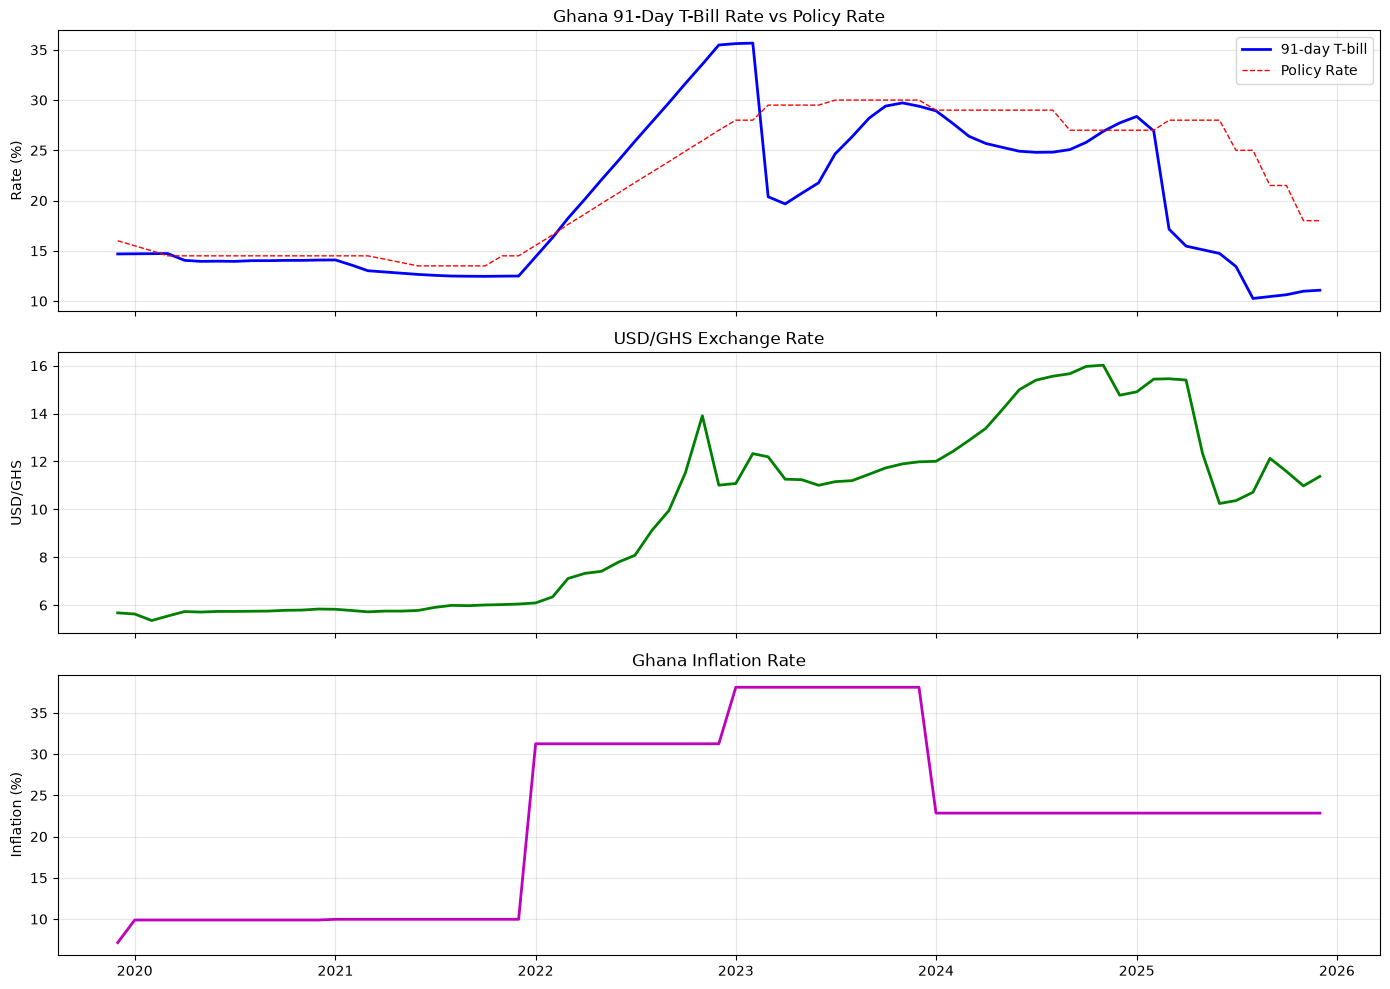

Chart saved!


In [21]:
# Save master dataset
master_full.to_csv('../data/master_dataset.csv', index=False)
print("Saved to data/master_dataset.csv")

# Quick visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(master_full['date'], master_full['tbill_91'], 'b-', linewidth=2, label='91-day T-bill')
axes[0].plot(master_full['date'], master_full['policy_rate'], 'r--', linewidth=1, label='Policy Rate')
axes[0].set_ylabel('Rate (%)')
axes[0].set_title('Ghana 91-Day T-Bill Rate vs Policy Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(master_full['date'], master_full['usd_ghs'], 'g-', linewidth=2)
axes[1].set_ylabel('USD/GHS')
axes[1].set_title('USD/GHS Exchange Rate')
axes[1].grid(True, alpha=0.3)

axes[2].plot(master_full['date'], master_full['inflation'], 'm-', linewidth=2)
axes[2].set_ylabel('Inflation (%)')
axes[2].set_title('Ghana Inflation Rate')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/overview_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")